# Pranuj Mandavia - Car Price Prediction Model Project

## I will be building a linear regression model to predict the prices of cars. The dataset used contains the name of the used cars, year, selling price, current price, number of kilometers driven, type of fuel used, and much more.

## Step 1: Import all Required Packages

In [62]:
# install & import all required libraries

%pip install scikit-learn 
%pip install statsmodels 
%pip install scipy
%pip install numpy 
%pip install pandas 
%pip install matplotlib 
%pip install seaborn


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from statsmodels.stats.diagnostic import normal_ad
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Step 2: Import & Pre-Process the Dataset

In [45]:
# import the dataset

df = pd.read_csv('./car_data.csv')

# pre-process the dataset 

df.info()

# check how many unique car names are in the dataset

df['Car_Name'].nunique()

# for this project, we don't need the car names, so remove this column

df.drop('Car_Name', axis = 1, inplace = True)

# check results

df.info()
df.head() 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           301 non-null    int64  
 1   Selling_Price  301 non-null    float64
 2   Present_Price  301 non-null    float64
 3   Kms_Driven     301 n

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [46]:
# instead of the year of the car, we want it's age
# age = difference between max year in the dataset and the year of that particular car
# then drop the 'Year' column

df.insert(0, 'Age', df['Year'].max() + 1 - df['Year'])
df.drop('Year', axis = 1, inplace = True)

df.head() # check results

,Age,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,5,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,6,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,8,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,5,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Step 3: Find Outliers in the Dataset

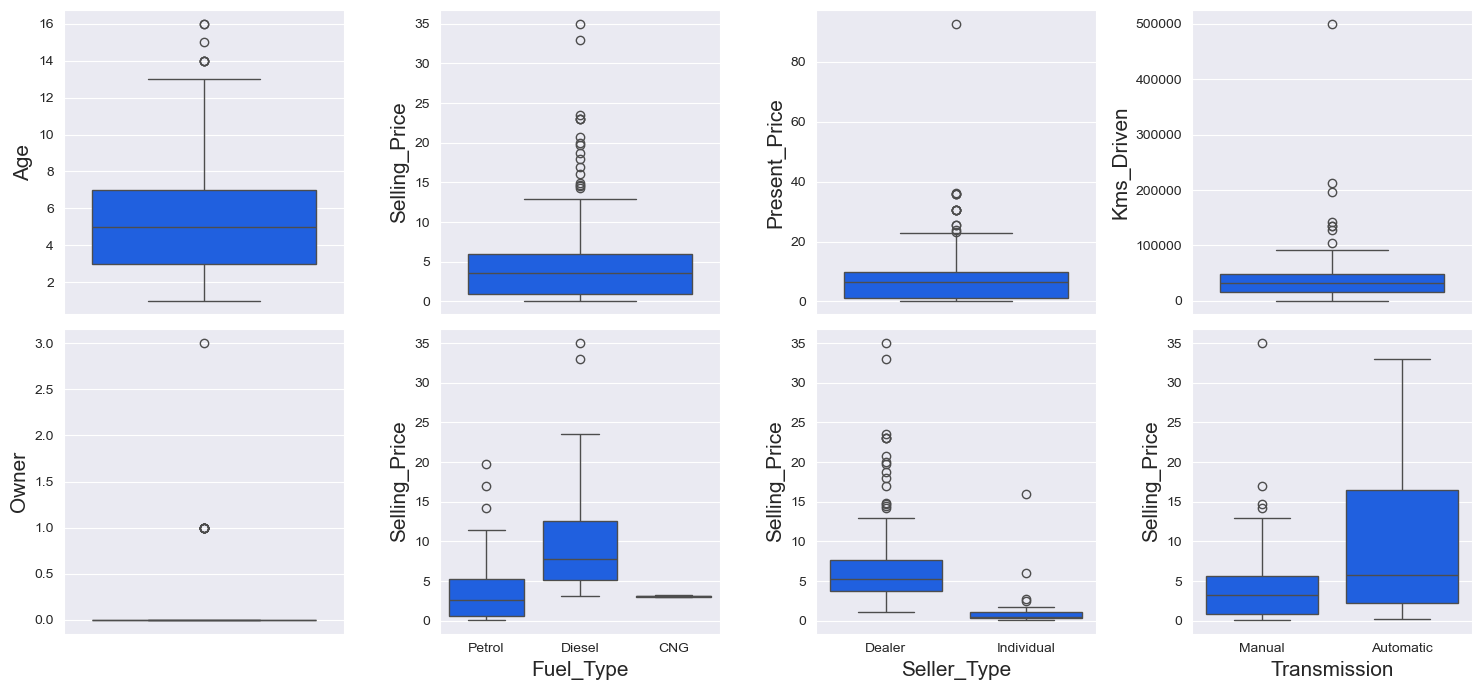

In [47]:
# separate numerical and categorical columns, then concatenate to order them (numerical first, categorical last)
# note that categorical columns have data type of 'object' in pandas

sns.set_style('darkgrid')
colors = ['#0055ff', '#ff7000', '#23bf00']

CustomPalette = sns.set_palette(sns.color_palette(colors))
OrderedCols = np.concatenate([df.select_dtypes(exclude = 'object').columns.values,  df.select_dtypes(include = 'object').columns.values])

fig, ax = plt.subplots(2, 4, figsize = (15, 7), dpi = 100)

# plot a boxplot for each column in the 2x4 grid using seaborn library
# numerical columns are plotted alone, categorical columns are plotted against Selling_Price

for i, col in enumerate(OrderedCols):

    x = i // 4
    y = i % 4

    if i < 5:

        sns.boxplot(data = df, y = col, ax = ax[x, y])
        ax[x, y].yaxis.label.set_size(15)

    else:

        sns.boxplot(data = df, x = col, y = 'Selling_Price', ax = ax[x, y])
        ax[x, y].xaxis.label.set_size(15)
        ax[x, y].yaxis.label.set_size(15)

plt.tight_layout()    
plt.show()

In [24]:
# let's find outliers using the InterQuartile Range rule

# divide dataset into four equal parts & focus on range of values within the middle 50 percent of data
# use the data within in this range to identify potential outliers

# find min & max quantile values for each unique value in the categorical columns
# filter the outlier samples that don't fit in the 25th & 75th percentile of target column (Selling Price)

outliers_indexes = []
target = 'Selling_Price'

for col in df.select_dtypes(include = 'object').columns:

    for cat in df[col].unique():

        df1 = df[df[col] == cat]
        q1 = df1[target].quantile(0.25)
        q3 = df1[target].quantile(0.75)
        iqr = q3-q1

        maximum = q3 + (1.5 * iqr)
        minimum = q1 - (1.5 * iqr)

        outlier_samples = df1[(df1[target] < minimum) | (df1[target] > maximum)]
        outliers_indexes.extend(outlier_samples.index.tolist())

# outliers in numerical columns can be filtered by the 25th & 75th percentiles of the same column

for col in df.select_dtypes(exclude = 'object').columns:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3-q1

    maximum = q3 + (1.5 * iqr)
    minimum = q1 - (1.5 * iqr)

    outlier_samples = df[(df[col] < minimum) | (df[col] > maximum)]
    outliers_indexes.extend(outlier_samples.index.tolist())

outliers_indexes = list(set(outliers_indexes))
print('{} outliers identified, indices are:\n\n{}'.format(len(outliers_indexes), outliers_indexes))

38 outliers identified, indices are:

[27, 37, 39, 50, 51, 52, 53, 54, 179, 184, 58, 59, 189, 62, 63, 64, 191, 66, 192, 196, 69, 193, 198, 201, 77, 205, 79, 80, 82, 84, 85, 86, 92, 93, 96, 97, 106, 241]


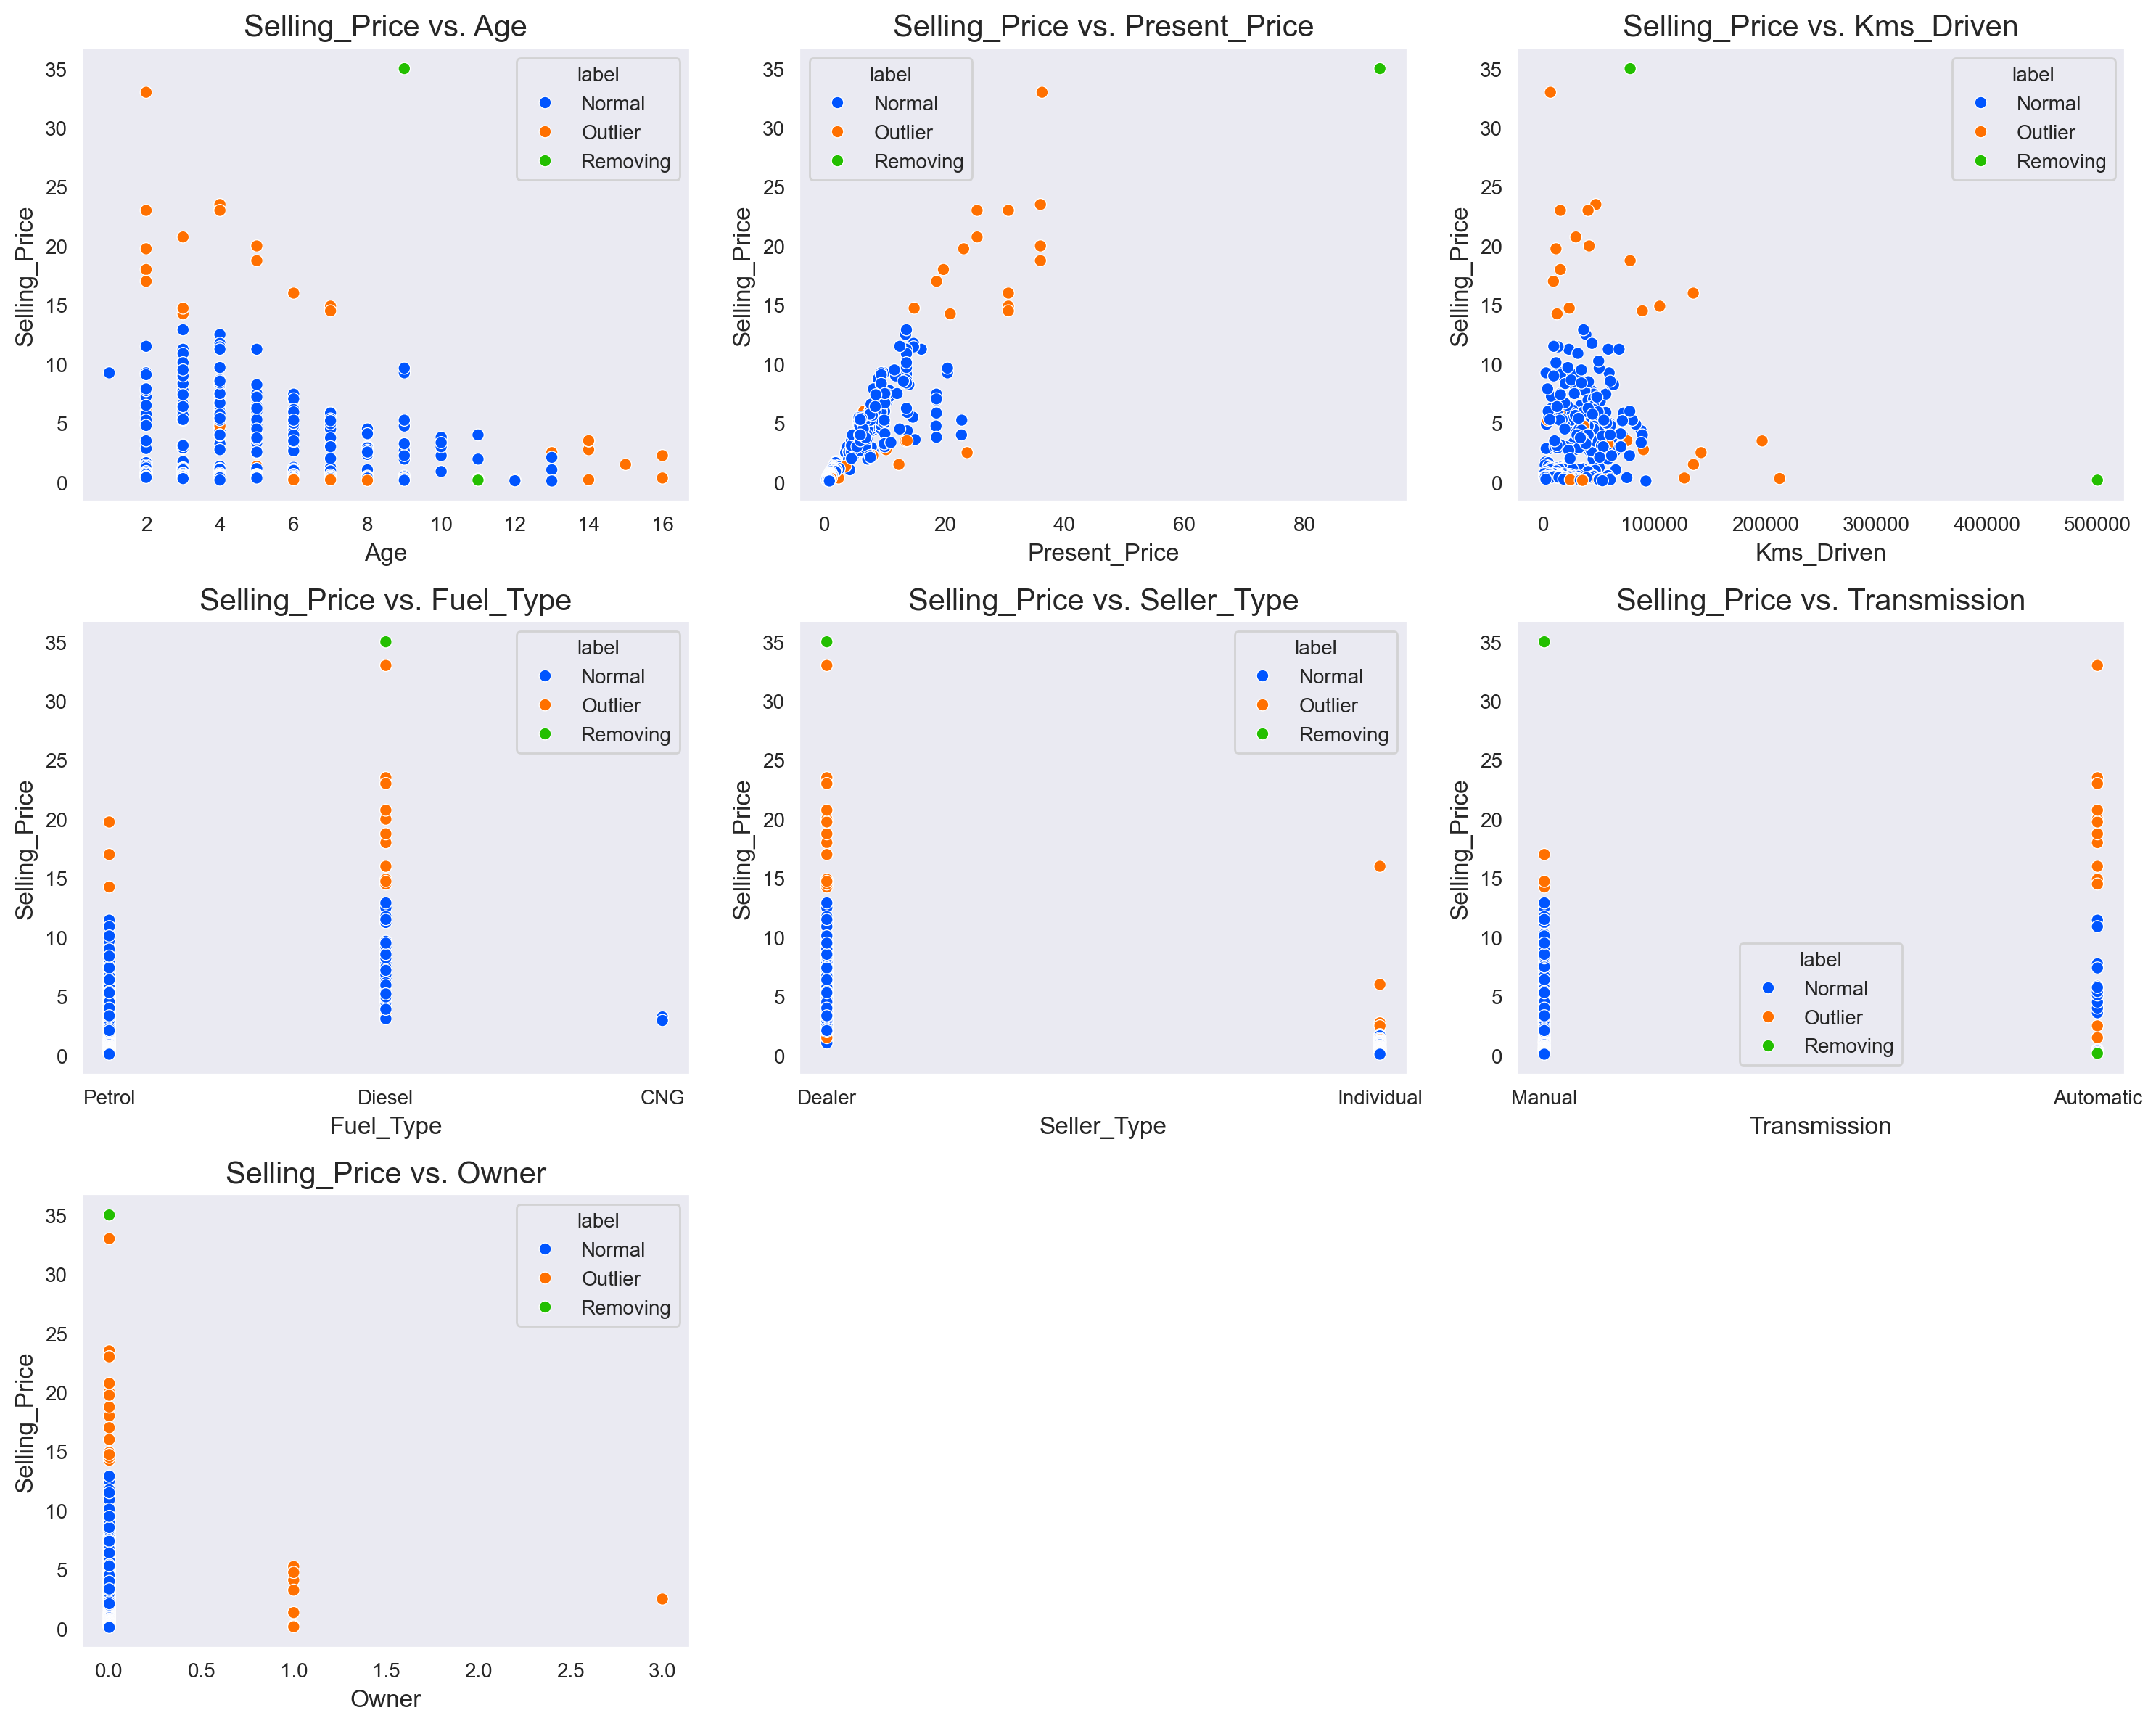

In [48]:
# let's find perfect outliers (where selling price is over 33k & car driven over 400k kilometers)
# save all indices in removing_indices variable & plot them in scatterplot format comparing each column against our target column

# label outliers

df1 = df.copy()
df1['label'] = 'Normal'
df1.loc[outliers_indexes,'label'] = 'Outlier'

# remove outliers

removing_indices = []
removing_indices.extend(df1[df1[target] > 33].index)
removing_indices.extend(df1[df1['Kms_Driven'] > 400000].index)
df1.loc[removing_indices,'label'] = 'Removing'

# plot scatterplot

target = 'Selling_Price'
features = df.columns.drop(target)
colors = ['#0055ff','#ff7000','#23bf00']
CustomPalette = sns.set_palette(sns.color_palette(colors))
fig, ax = plt.subplots(nrows = 3 ,ncols = 3, figsize = (15, 12), dpi = 200)

for i in range(len(features)):

    x = i // 3
    y = i % 3

    sns.scatterplot(data = df1, x = features[i], y = target, hue = 'label', ax = ax[x, y])
    ax[x, y].set_title('{} vs. {}'.format(target, features[i]), size = 15)
    ax[x, y].set_xlabel(features[i], size = 12)
    ax[x, y].set_ylabel(target, size = 12)
    ax[x, y].grid()

ax[2, 1].axis('off')
ax[2, 2].axis('off')

plt.tight_layout()
plt.show()


In [31]:
# view the perfect outliers

removing_indices = list(set(removing_indices))
removing_indices

# before we remove them, check for null values in the dataset

df.isnull().sum() # no null values

# remove outliers

df1 = df.copy()
df1.drop(removing_indices, inplace = True)
df1.reset_index(drop = True, inplace = True)

# check results 

df1.info()
df1.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            299 non-null    int64  
 1   Selling_Price  299 non-null    float64
 2   Present_Price  299 non-null    float64
 3   Kms_Driven     299 non-null    int64  
 4   Fuel_Type      299 non-null    object 
 5   Seller_Type    299 non-null    object 
 6   Transmission   299 non-null    object 
 7   Owner          299 non-null    int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 18.8+ KB


,Age,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,5,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,6,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,8,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,5,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Step 4: Analyze Dataset

### Selling Price vs Numerical Features Bivariate Analysis


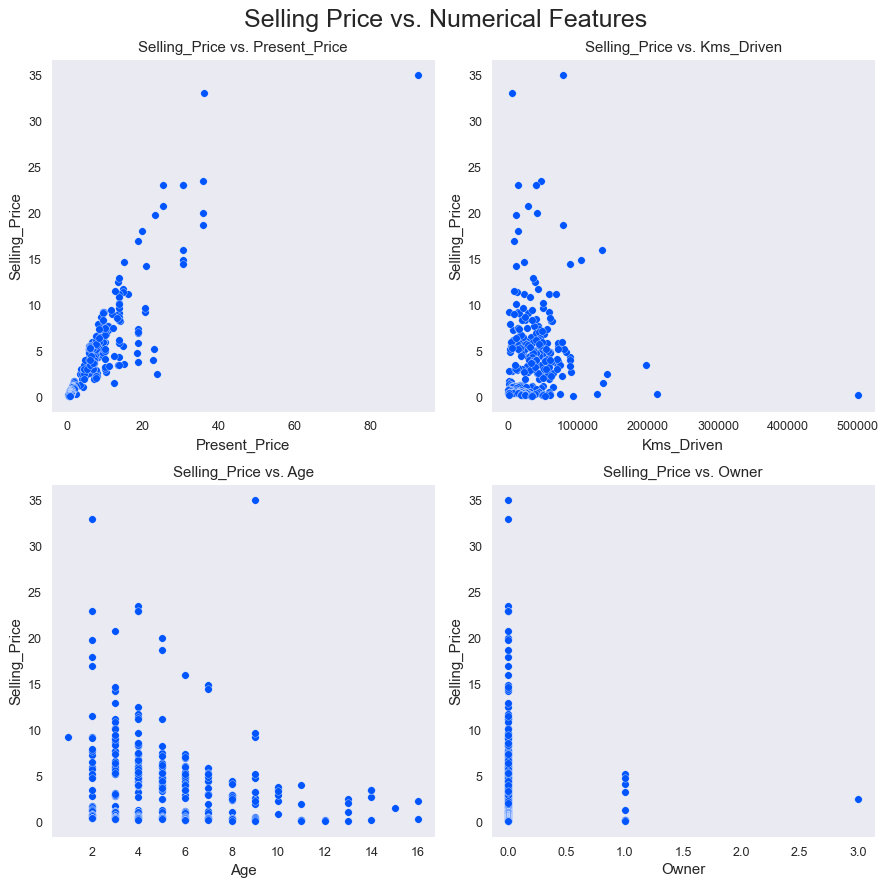

In [49]:
# let's analyze the relationship between the numerical features & the selling price using bivariate analysis
# numerical columns will be plotted in a scatterplot

fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 10), dpi = 90)
num_features = ['Present_Price', 'Kms_Driven', 'Age', 'Owner']
target = 'Selling_Price'
c = '#0055ff'

for i in range(len(num_features)):

    row = i // 2
    col = i % 2

    ax[row, col].scatter(df1[num_features[i]], df1[target], color = c, edgecolors = 'w', linewidths = 0.25)
    ax[row, col].set_title('{} vs. {}'.format(target, num_features[i]), size = 12)
    ax[row, col].set_xlabel(num_features[i], size = 12)
    ax[row, col].set_ylabel(target, size = 12)
    ax[row, col].grid()

plt.suptitle('Selling Price vs. Numerical Features', size = 20)
plt.tight_layout()
plt.show()

### Selling Price vs Categorical Features Bivariate Analysis


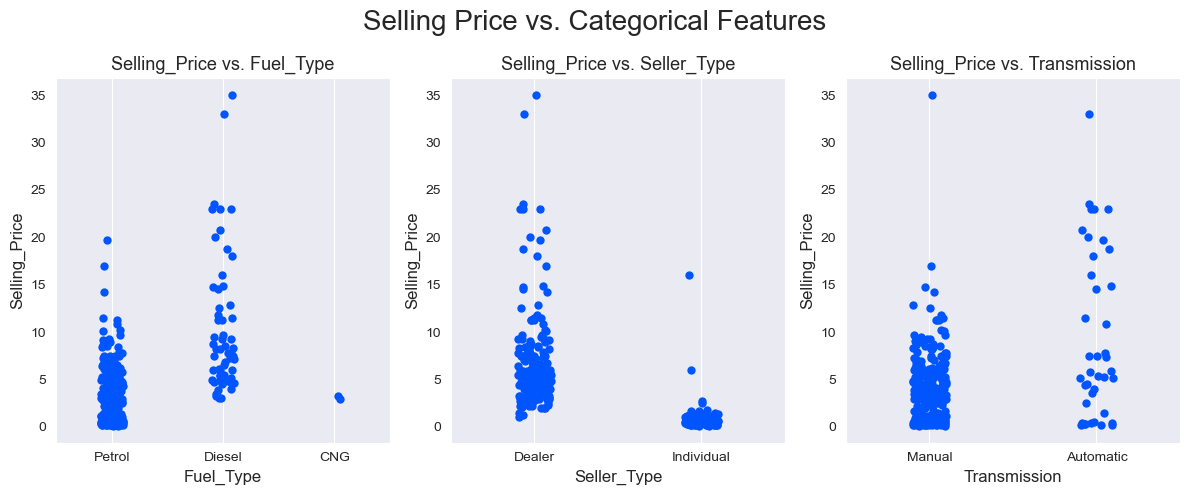

In [50]:
# let's analyze the relationship between the categorical features & the selling price using bivariate analysis
# categorical columns will be plotted in a stripplot

fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 5), dpi = 100)
cat_features = ['Fuel_Type', 'Seller_Type', 'Transmission']
target = 'Selling_Price'
c = '#0055ff'

for i in range(len(cat_features)):

    sns.stripplot(ax = axes[i], x = cat_features[i], y = target, data = df1, size = 6, color = c)
    axes[i].set_title('{} vs. {}'.format(target, cat_features[i]), size = 13)
    axes[i].set_xlabel(cat_features[i], size = 12)
    axes[i].set_ylabel(target, size = 12)
    axes[i].grid()

plt.suptitle('Selling Price vs. Categorical Features', size = 20)
plt.tight_layout()
plt.show()

### Bivariate Analysis Conclusions

##### As Present Price increases, Selling Price also increases (directly proportional)
##### As Age increases, Selling Price decreases (inversely proportional)
##### As Kilometers Driven increases, Selling Price decreases (inversely proportional)
##### As the number of previous car owners increases, its Selling Price decreases (inversely proportional)
##### Diesel > CNG > Petrol in terms of Selling Price for cars by fuel type
##### Selling Price of cars sold by car dealers is higher than the price of those sold by individuals
##### Automatic cars are more expensive than manual cars 

### Encoding Categorical Variables

In [51]:
# categorical columns must be converted to numerical columns 

# first, let's split the Fuel column into two columns (Fuel_Type_Petrol & Fuel_Type_Diesel)
# if a car runs on petrol, the Fuel_Type_Petrol column is set to 1 (True) and Fuel_Type_Diesel is set to 0 (False)
# if a car runs on diesel, the Fuel_Type_Diesel column is set to 1 (True) and Fuel_Type_Petrol is set to 0 (False)

CatCols = ['Fuel_Type', 'Seller_Type', 'Transmission']

df1 = pd.get_dummies(df1, columns = CatCols, drop_first = True)
df1.head(5)


,Age,Selling_Price,Present_Price,Kms_Driven,Owner,label,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,5,3.35,5.59,27000,0,Normal,False,True,False,True
1,6,4.75,9.54,43000,0,Normal,True,False,False,True
2,2,7.25,9.85,6900,0,Normal,False,True,False,True
3,8,2.85,4.15,5200,0,Normal,False,True,False,True
4,5,4.60,6.87,42450,0,Normal,True,False,False,True


### Correlation Analysis

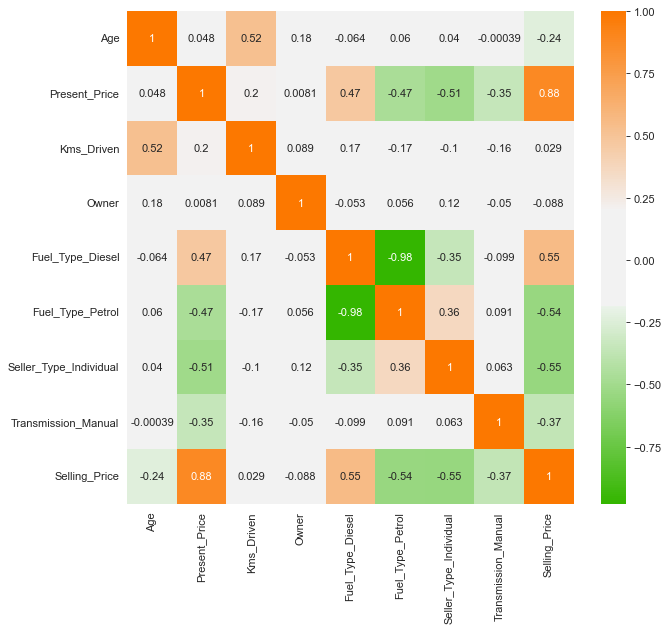

In [53]:
# find the correlation matrix for each category with relation to Selling Price
# correlation is directly proportional if values are positive & inversely proportional if values are negative

target = 'Selling_Price' 
cmap = sns.diverging_palette(125, 28, s = 100, l = 65, sep = 50, as_cmap = True)
fig, ax = plt.subplots(figsize = (9, 8), dpi = 80)

numerical_df = df1.select_dtypes(exclude='object')  # drop categorical columns before correlating

ax = sns.heatmap(pd.concat([numerical_df.drop(target, axis = 1), numerical_df[target]], axis = 1).corr(), annot = True, cmap = cmap)
plt.show()

### Correlation Matrix Conclusion

#### From the above matrix, we can infer that Selling Price is highly correlated with Present Price, Seller Type, and Fuel Type

## Step 5: Building the Model

### Split the Dataset

In [57]:
# remove Selling_Price from input and set it to output (has to be predicted)

x = df1.drop('Selling_Price', axis = 1).select_dtypes(exclude = 'object')  # keep numerical features only

y = df1['Selling_Price']

# take 70 percent of data for training & 30 percent for testing

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 0)

# make a backup of test data (need it for final comparison)

y_test_actual = y_test


### Normalize the Dataset

In [58]:
# use StandardScaler to transform each data so each feature has mean of 0 & standard deviation of 1

scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

### Train the Model

In [59]:
# train the model

linear_reg = LinearRegression()
linear_reg.fit(x_train_scaled, y_train)

# find intercept and coefficient for each column in training dataset

pd.DataFrame(data = np.append(linear_reg.intercept_ , linear_reg.coef_), index = ['Intercept'] + [col + " Coef." for col in x.columns], columns = ['Value']).sort_values('Value', ascending = False)


,Value
Intercept,4.459143
Present_Price Coef.,3.652055
Fuel_Type_Diesel Coef.,1.038032
Fuel_Type_Petrol Coef.,0.260946
Owner Coef.,-0.210863
Kms_Driven Coef.,-0.248282
Transmission_Manual Coef.,-0.437628
Seller_Type_Individual Coef.,-0.664741
Age Coef.,-1.074787


### Evaluate the Model

In [60]:
# use scikit learn to determine metrics such as mean squared error (MSE), mean absolute error (MAE), root mean squared error (RMSE), & R2 score


def model_evaluation(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)

    MAE = metrics.mean_absolute_error(y_test, y_pred)
    MSE = metrics.mean_squared_error(y_test, y_pred)
    RMSE = np.sqrt(MSE)
    R2_Score = metrics.r2_score(y_test, y_pred)

    return pd.DataFrame([MAE, MSE, RMSE, R2_Score], index = ['MAE', 'MSE', 'RMSE' ,'R2-Score'], columns = [model_name])

model_evaluation(linear_reg, x_test_scaled, y_test, 'Linear Reg.')

,Linear Reg.
MAE,1.242671
MSE,4.432128
RMSE,2.105262
R2-Score,0.851798


### Evaluate Model Using K-Fold Cross-Validation

In [63]:
# dataset divided into k equal-sized subsets / folds 
# model is trained & evaluated k times, each time using a different fold the validation set & the other folds as the training set

# results are then averaged to obtain a better estimate of the performance of the model
# each data point being used for both training & validation reduces the risk of bias during evaluation

linear_reg_cv = LinearRegression()
scaler = StandardScaler()
pipeline = make_pipeline(StandardScaler(),  LinearRegression())

kf = KFold(n_splits = 6, shuffle = True, random_state = 0) 
scoring = ['neg_mean_absolute_error', 'neg_mean_squared_error', 'neg_root_mean_squared_error', 'r2']
result = cross_validate(pipeline, x, y, cv = kf, return_train_score = True, scoring = scoring)

MAE_mean = (-result['test_neg_mean_absolute_error']).mean()
MAE_std = (-result['test_neg_mean_absolute_error']).std()
MSE_mean = (-result['test_neg_mean_squared_error']).mean()
MSE_std = (-result['test_neg_mean_squared_error']).std()
RMSE_mean = (-result['test_neg_root_mean_squared_error']).mean()
RMSE_std = (-result['test_neg_root_mean_squared_error']).std()
R2_Score_mean = result['test_r2'].mean()
R2_Score_std = result['test_r2'].std()

pd.DataFrame({'Mean': [MAE_mean,MSE_mean,RMSE_mean,R2_Score_mean], 'Std': [MAE_std,MSE_std,RMSE_std,R2_Score_std]}, index = ['MAE', 'MSE', 'RMSE' ,'R2-Score'])


,Mean,Std
MAE,1.251055,0.211388
MSE,4.088247,2.325318
RMSE,1.941347,0.565172
R2-Score,0.842114,0.048023


## Step 6: Results Visualization

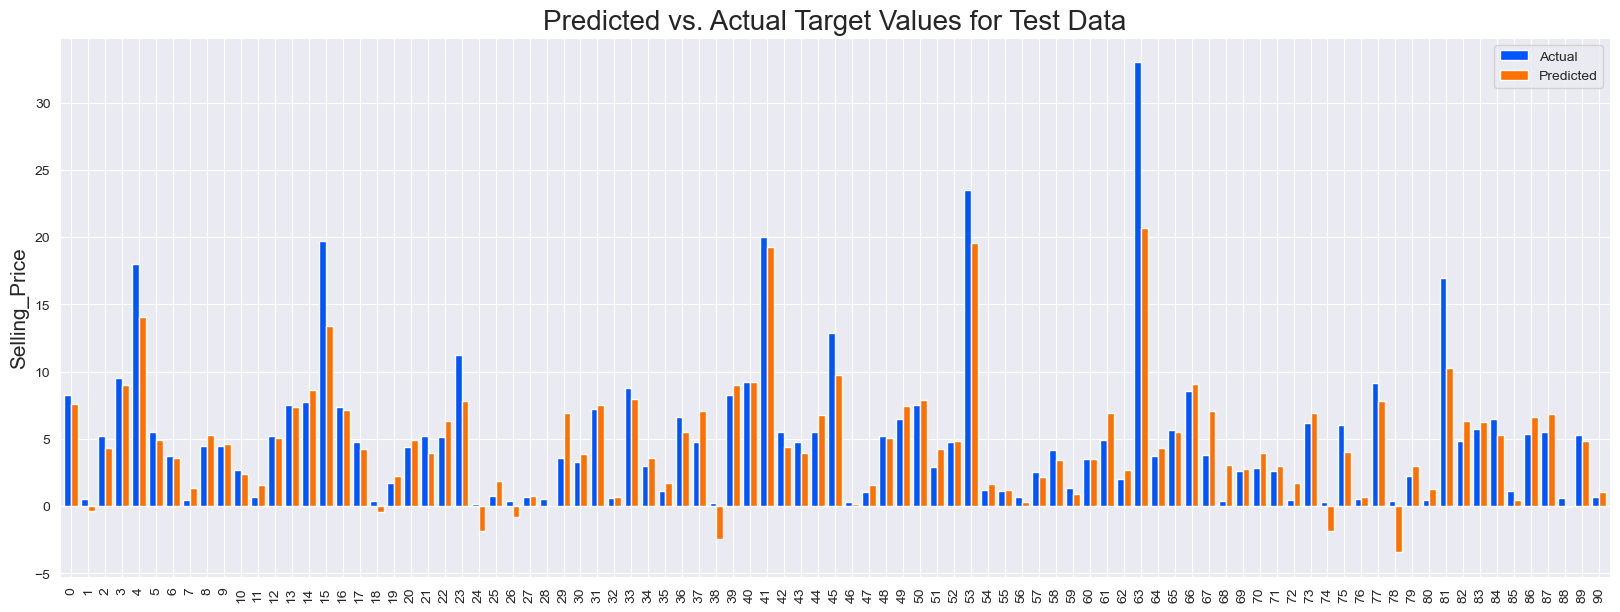

In [64]:
# create a dataframe with the actual and predicted values

y_test_pred = linear_reg.predict(x_test_scaled)
df_comp = pd.DataFrame({'Actual' : y_test_actual, 'Predicted' : y_test_pred})

# compare the actual & predicted target values for the test data using a bar plot


def compare_plot(df_comp):

    df_comp.reset_index(inplace = True)
    df_comp.plot(y = ['Actual','Predicted'], kind = 'bar', figsize = (20, 7), width = 0.8)
    plt.title('Predicted vs. Actual Target Values for Test Data', fontsize = 20)
    plt.ylabel('Selling_Price', fontsize = 15)
    plt.show()

compare_plot(df_comp)

### In the above graph, the blue lines indicate the actual price and orange lines indicate the predicted price of the cars. Some predicted values are negative. The model isn't perfect but it did pretty well. 